In [1]:
import logging
import os
import random

os.environ["KERAS_BACKEND"] = "torch"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "0"

import keras
import matplotlib.pyplot as plt
import numpy as np
from keras import callbacks, layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

from xasml import resource_path
from xasml.datasets.fdmnes import FE_REFERENCE_MBARN
from xasml.models.data import Processor
from xasml.models.io import read_from_h5
from xasml.models.metrics import calculate_accuracies, display_metrics

In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger("xasml.cnn_classifier_augmented")
logger.setLevel(logging.INFO)

plt.style.use("stylelib/presentation.mplstyle")

In [3]:
# Define some constants.
ELEMENT = "Fe"
JOB = "job15"
RESOURCE = "xasml:datasets/fdmnes/materials.h5"
ENERGY_SHIFT = 7112
ENERGY_MIN = -10 + ENERGY_SHIFT
ENERGY_MAX = 60 + ENERGY_SHIFT
LABELS = ["O:6", "T:4"]
NORMALIZATION = "area"  # Z-score fails when adding noise.
OUTLIER_THRESHOLD = 4
THRESHOLD = 0.5
PREFIX = os.path.join("figures", "cnn_classifier_augmented")
EXTENSION = "pdf"
DPI = 300

# The original (un-augmented) model trained in cnn_classifier.ipynb is reused
# here as the baseline for comparison.
ORIGINAL_MODEL_PATH = "cnn_classifier.keras"
AUGMENTED_MODEL_NAME = "cnn_classifier_augmented"

# Augmentation parameters. The CNN is robust to noise and self-absorption but
# fragile to energy shifts, so augmentation is focused on shifts only, with a
# slightly wider range and a larger fraction than the mixed scheme used for the
# random forest. The validation set is augmented as well as the training set so
# that early stopping selects for shift robustness.
AUGMENT_KWARGS = {
    "fraction": 2 / 3,
    "shift_range": (-1.5, 1.5),
    "snr_range": None,
    "normalization": NORMALIZATION,
}

# Read data from file.
X, y, metas = read_from_h5(resource_path(RESOURCE), ELEMENT, JOB)

# Create a processor object.
processor = Processor(X, y, metas=metas)

In [4]:
def train_model(
    model,
    data,
    epochs=512,
    patience=64,
    learning_rate=1e-3,
    batch_size=32,
    class_weight=None,
):
    """Train a model using the given data and hyperparameters."""
    # Compile the model.
    model.compile(
        loss="binary_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"],
    )

    # Define the callbacks.
    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )

    save_best = callbacks.ModelCheckpoint(
        f"{model.name}.keras",
        monitor="val_loss",
        verbose=0,
        save_best_only=True,
        mode="min",
        save_freq="epoch",
        initial_value_threshold=None,
    )

    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=patience // 2, min_lr=1e-6, verbose=1
    )

    # Train the model.
    history = model.fit(
        data.X_train,
        data.y_train,
        validation_data=(data.X_val, data.y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping, save_best, reduce_lr],
        verbose=1,
        class_weight=class_weight,
    )
    return history


def evaluate_model(model, data, history: keras.callbacks.History | None = None):
    """Evaluate the model using the given data and history."""
    # Recompile if the optimizer is missing (workaround for Keras 3 + Torch + restore_best_weights).
    if not hasattr(model, "optimizer"):
        model.compile(
            loss="binary_crossentropy",
            optimizer="adam",
            metrics=["accuracy"],
        )

    # Evaluate the model on the test set.
    _, test_acc = model.evaluate(data.X_test, data.y_test)

    # Print the test accuracy.
    print(f"Test accuracy: {test_acc:.3f}")

    if history is not None:
        # Plot the training and validation loss
        fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
        ax1, ax2 = ax

        ax1.plot(history.history["accuracy"], label="Training accuracy")
        ax1.plot(history.history["val_accuracy"], label="Validation accuracy")
        ax1.legend()
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Accuracy")

        ax2.plot(history.history["loss"], label="Training loss")
        ax2.plot(history.history["val_loss"], label="Validation loss")
        ax2.legend()
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Loss")

        fig.tight_layout()
        fig.savefig(f"{PREFIX}_history.{EXTENSION}", dpi=DPI)

    return test_acc

In [5]:
label_encoder = LabelEncoder()
processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

# Convert the labels to integers as required by the sigmoid activation function.
label_encoder.fit(processor.y)
processor.y = np.array(label_encoder.transform(processor.y))

energies_full = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT

# Screen the outliers on the analysis window, as the un-augmented model does, then
# restore the full energy grid for the spectra that were kept. The augmentation
# shifts applied in a later cell then act on the full grid, so the positions they
# vacate fall outside the analysis window. The evaluation shift is applied before
# the trim for the same reason.
X_full = np.copy(processor.X)
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies_full)
energies = energies_full[mask]
keep = processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.set_features("all", X_full[keep])

# Explicitly shuffle the data to ensure random splits, preventing ordered data bias.
processor.split(
    test_size=0.15, val_size=0.15, random_seed=RANDOM_SEED, shuffle=True, stratify=True
)

# The test set is never augmented, so reduce it to the analysis window now.
processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies_full, subset="test")
processor.normalize(method=NORMALIZATION, reference=energies, subset="test")

2026-08-17 22:51:25,384 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:51:25,385 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:51:28,020 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:51:28,026 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:51:28,057 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


2026-08-17 22:51:28,070 - xasml.models.data - INFO - Removed 129 outlier(s) out of 2863 spectra (threshold=4, min_std=0.01).


2026-08-17 22:51:28,083 - xasml.models.data - INFO - Split data into training, testing, and validation sets.


2026-08-17 22:51:31,809 - xasml.models.data - INFO - Trimmed features in the 'test' subset to the range 7102 to 7172.


2026-08-17 22:51:31,811 - xasml.models.data - INFO - Normalized the 'test' subset using the 'area' method.


## Original model

Reuse the un-augmented model trained in `cnn_classifier.ipynb` as the baseline.

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


2026-08-17 22:51:32,253 - xasml.models.metrics - INFO - Balanced accuracy: 92.3%


2026-08-17 22:51:32,253 - xasml.models.metrics - INFO -   O:6: 95.5%


2026-08-17 22:51:32,253 - xasml.models.metrics - INFO -   T:4: 89.1%


2026-08-17 22:51:32,255 - xasml.models.metrics - INFO - Accuracy: 93.7%


2026-08-17 22:51:32,255 - xasml.models.metrics - INFO - F1 score: 93.7%


Original model - unperturbed test set:


{'accuracy': 0.9367396593673966,
 'balanced': 0.9231178772879015,
 np.str_('O:6'): 0.9554794520547946,
 np.str_('T:4'): 0.8907563025210085}

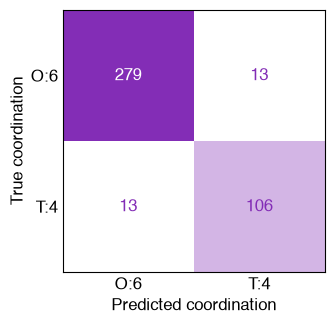

In [6]:
if not os.path.exists(ORIGINAL_MODEL_PATH):
    raise FileNotFoundError(
        f"Original model not found: {ORIGINAL_MODEL_PATH}. "
        "Run cnn_classifier.ipynb first to train and save it."
    )
model_orig = keras.models.load_model(ORIGINAL_MODEL_PATH, compile=False)

y_pred = model_orig.predict(processor.X_test)
y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])
print("Original model - unperturbed test set:")
display_metrics(
    label_encoder.inverse_transform(processor.y_test),
    label_encoder.inverse_transform(y_pred),
    display_labels=LABELS,
    cm_name=f"{PREFIX}_original_cm.{EXTENSION}",
    dpi=DPI,
)

## Augmented model

Augment the training and validation sets with shifted copies, then train a
fresh CNN. The test set is left unperturbed.

In [7]:
# Augment the training and validation sets with perturbed spectra. The shifts act
# on the full energy grid, so no edge value is repeated inside the analysis window.
# Normalization is deferred until after the trim below.
AUGMENT_KWARGS_FULL = {**AUGMENT_KWARGS, "normalization": None}
processor.augment(
    energies=energies_full, random_seed=RANDOM_SEED, **AUGMENT_KWARGS_FULL
)
processor.augment(
    energies=energies_full,
    random_seed=RANDOM_SEED + 1,
    subset="val",
    **AUGMENT_KWARGS_FULL,
)

# Reduce the augmented subsets to the analysis window and normalize them.
for subset in ("train", "val"):
    processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies_full, subset=subset)
    processor.normalize(method=NORMALIZATION, reference=energies, subset=subset)

print(f"Training set shape: {processor.X_train.shape}")
print(f"Validation set shape: {processor.X_val.shape}")

2026-08-17 22:51:32,511 - xasml.models.data - INFO - Augmented 'train' subset with 1275 samples (shift: 1275, noise: 0, self-absorption: 0). Total: 3188 samples.


2026-08-17 22:51:32,516 - xasml.models.data - INFO - Augmented 'val' subset with 273 samples (shift: 273, noise: 0, self-absorption: 0). Total: 683 samples.


2026-08-17 22:51:32,522 - xasml.models.data - INFO - Trimmed features in the 'train' subset to the range 7102 to 7172.


2026-08-17 22:51:32,533 - xasml.models.data - INFO - Normalized the 'train' subset using the 'area' method.


2026-08-17 22:51:32,534 - xasml.models.data - INFO - Trimmed features in the 'val' subset to the range 7102 to 7172.


2026-08-17 22:51:32,536 - xasml.models.data - INFO - Normalized the 'val' subset using the 'area' method.


Training set shape: (3188, 701)
Validation set shape: (683, 701)


## Classifier

In [8]:
# Re-seed immediately before building the model so the weight initialisation is
# reproducible across runs.
keras.utils.set_random_seed(RANDOM_SEED)

CONV_KW = {"activation": "relu", "padding": "same", "kernel_initializer": "he_normal"}
DENSE_KW = {"activation": "relu", "kernel_initializer": "he_normal"}

model = models.Sequential(name=AUGMENTED_MODEL_NAME)
model.add(layers.Input(shape=(len(energies),)))
model.add(layers.Reshape((len(energies), 1)))

# Block 1: 8 filters
model.add(layers.Conv1D(8, 3, **CONV_KW))
model.add(layers.Conv1D(8, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 2: 16 filters
model.add(layers.Conv1D(16, 3, **CONV_KW))
model.add(layers.Conv1D(16, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 3: 32 filters
model.add(layers.Conv1D(32, 3, **CONV_KW))
model.add(layers.Conv1D(32, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Block 4: 64 filters
model.add(layers.Conv1D(64, 3, **CONV_KW))
model.add(layers.Conv1D(64, 3, **CONV_KW))
model.add(layers.MaxPooling1D(2))

# Dense head
model.add(layers.Flatten())
model.add(layers.Dense(64, **DENSE_KW))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(32, **DENSE_KW))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation="sigmoid"))

model.summary()

Model: "cnn_classifier_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 701, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 701, 8)         │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 701, 8)         │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 350, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 350, 16)        │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 350, 16)        │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 175, 32)        │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 175, 32)        │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 87, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 87, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 87, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       176,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,953 (792.79 KB)

 Trainable params: 202,953 (792.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model_path = f"{model.name}.keras"

classes = np.unique(processor.y_train)
weights = class_weight.compute_class_weight(
    "balanced", classes=classes, y=processor.y_train
)
class_weights = dict(zip(classes, weights))
print(f"Class weights: {class_weights}")
print(f"Training set shape: {processor.X_train.shape}")
print(f"Validation set shape: {processor.X_val.shape}")

if os.path.exists(model_path):
    # Reuse the saved best model so re-runs reproduce the reported metrics.
    model = keras.models.load_model(model_path, compile=False)
    model.summary()
    history = None
else:
    history = train_model(
        model,
        processor,
        epochs=512,
        patience=32,
        learning_rate=1e-4,
        batch_size=32,
        class_weight=class_weights,
    )

Class weights: {np.int64(0): np.float64(0.7056219566179726), np.int64(1): np.float64(1.7158234660925726)}
Training set shape: (3188, 701)
Validation set shape: (683, 701)
Epoch 1/512


  1/100 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.6250 - loss: 0.7001

  4/100 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6797 - loss: 0.6651  

  7/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6875 - loss: 0.6730

 10/100 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6969 - loss: 0.6694

...

 94/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9535 - loss: 0.1253

 97/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9543 - loss: 0.1251

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9548 - loss: 0.1238


Epoch 131: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9548 - loss: 0.1238 - val_accuracy: 0.9283 - val_loss: 0.2111 - learning_rate: 2.5000e-05


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8750 - loss: 0.3574

 8/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9297 - loss: 0.1869 

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9367 - loss: 0.1654


Test accuracy: 0.937


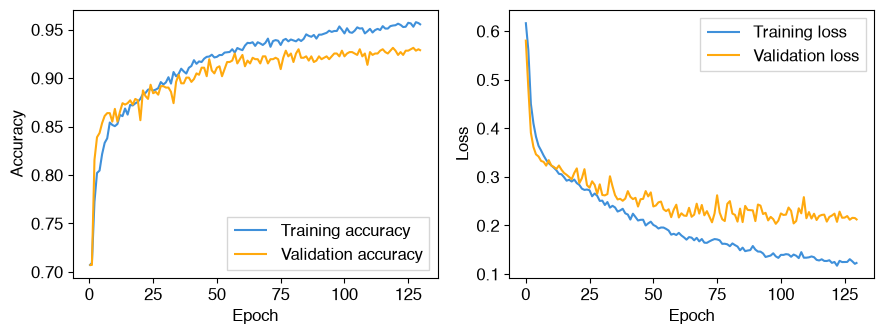

In [10]:
accuracy = evaluate_model(model, processor, history)

 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

11/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


2026-08-17 22:56:39,332 - xasml.models.metrics - INFO - Balanced accuracy: 92.1%


2026-08-17 22:56:39,332 - xasml.models.metrics - INFO -   O:6: 95.9%


2026-08-17 22:56:39,332 - xasml.models.metrics - INFO -   T:4: 88.2%


2026-08-17 22:56:39,334 - xasml.models.metrics - INFO - Accuracy: 93.7%


2026-08-17 22:56:39,334 - xasml.models.metrics - INFO - F1 score: 93.7%


Augmented model - unperturbed test set:


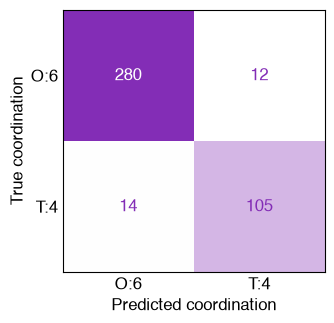

In [11]:
model_path = f"{model.name}.keras"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found: {model_path}")

model = keras.models.load_model(model_path, compile=False)

y_pred = model.predict(processor.X_test)
y_pred = np.array([1 if value >= THRESHOLD else 0 for value in y_pred])
print("Augmented model - unperturbed test set:")
display_metrics(
    label_encoder.inverse_transform(processor.y_test),
    label_encoder.inverse_transform(y_pred),
    display_labels=LABELS,
    cm_name=f"{PREFIX}_cm.{EXTENSION}",
    dpi=DPI,
)
model_aug = model

## Shift comparison

2026-08-17 22:56:39,452 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:56:39,452 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:56:42,808 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:56:42,818 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:56:42,828 - xasml.models.data - INFO - Shifting the features to the left by 10 indices.


...

2026-08-17 22:57:13,077 - xasml.models.metrics - INFO -   T:4: 85.7%


2026-08-17 22:57:13,079 - xasml.models.metrics - INFO - Balanced accuracy: 91.1%


2026-08-17 22:57:13,080 - xasml.models.metrics - INFO -   O:6: 95.5%


2026-08-17 22:57:13,080 - xasml.models.metrics - INFO -   T:4: 86.6%


2026-08-17 22:57:13,080 - xasml.cnn_classifier_augmented - INFO - Shift +1.0 eV, original: balanced=0.901 O:6=0.945 T:4=0.857; augmented: balanced=0.911 O:6=0.955 T:4=0.866


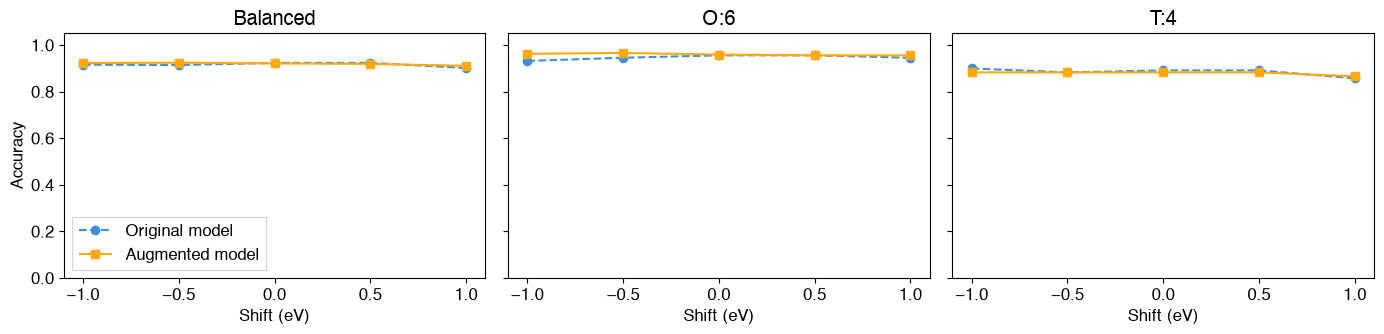

In [12]:
SHIFTS = [-1.0, -0.5, 0.0, 0.5, 1.0]
acc_orig_shift = []
acc_aug_shift = []
acc_orig_per_class = {label: [] for label in LABELS}
acc_aug_per_class = {label: [] for label in LABELS}

for shift in SHIFTS:
    # Reset all data and split it again as the shift will affect it.
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    processor.y = np.array(label_encoder.fit_transform(processor.y))
    energies = processor.metas[0]["energies"] + ENERGY_SHIFT
    processor.shift(shift, reference=energies)
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.normalize(method=NORMALIZATION, reference=energies)
    processor.split(
        test_size=0.15,
        val_size=0.15,
        random_seed=RANDOM_SEED,
        shuffle=True,
        stratify=True,
    )

    y_test = label_encoder.inverse_transform(processor.y_test)

    y_pred_orig = model_orig.predict(processor.X_test)
    y_pred_orig = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_orig])
    y_pred_aug = model_aug.predict(processor.X_test)
    y_pred_aug = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_aug])

    accs_orig = calculate_accuracies(
        y_test, label_encoder.inverse_transform(y_pred_orig)
    )
    accs_aug = calculate_accuracies(y_test, label_encoder.inverse_transform(y_pred_aug))

    acc_orig_shift.append(accs_orig["balanced"])
    acc_aug_shift.append(accs_aug["balanced"])
    for label in LABELS:
        acc_orig_per_class[label].append(accs_orig[label])
        acc_aug_per_class[label].append(accs_aug[label])

    logger.info(
        f"Shift {shift:+.1f} eV, original: balanced={accs_orig['balanced']:.3f} "
        + " ".join(f"{label}={accs_orig[label]:.3f}" for label in LABELS)
        + f"; augmented: balanced={accs_aug['balanced']:.3f} "
        + " ".join(f"{label}={accs_aug[label]:.3f}" for label in LABELS)
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)

axes[0].plot(SHIFTS, acc_orig_shift, marker="o", ls="--", label="Original model")
axes[0].plot(SHIFTS, acc_aug_shift, marker="s", ls="-", label="Augmented model")
axes[0].set_title("Balanced")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

for i, label in enumerate(LABELS):
    axes[i + 1].plot(
        SHIFTS, acc_orig_per_class[label], marker="o", ls="--", label="Original model"
    )
    axes[i + 1].plot(
        SHIFTS, acc_aug_per_class[label], marker="s", ls="-", label="Augmented model"
    )
    axes[i + 1].set_title(label)

for ax in axes:
    ax.set_xlabel("Shift (eV)")
    ax.set_ylim(0.0, 1.05)

fig.tight_layout()
fig.savefig(f"{PREFIX}_shift_comparison.{EXTENSION}", dpi=DPI)

## Noise comparison

2026-08-17 22:57:14,047 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:57:14,048 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:57:17,235 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:57:17,240 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:57:17,253 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


...

2026-08-17 22:57:47,353 - xasml.models.metrics - INFO -   T:4: 89.9%


2026-08-17 22:57:47,356 - xasml.models.metrics - INFO - Balanced accuracy: 92.2%


2026-08-17 22:57:47,356 - xasml.models.metrics - INFO -   O:6: 96.2%


2026-08-17 22:57:47,356 - xasml.models.metrics - INFO -   T:4: 88.2%


2026-08-17 22:57:47,356 - xasml.cnn_classifier_augmented - INFO - SNR 250, original: balanced=0.927 O:6=0.955 T:4=0.899; augmented: balanced=0.922 O:6=0.962 T:4=0.882


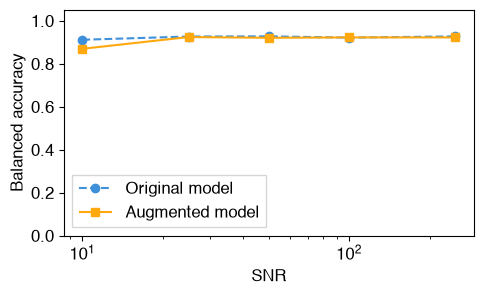

In [13]:
SNRS = [10, 25, 50, 100, 250]
acc_orig_noise = []
acc_aug_noise = []

for snr in SNRS:
    processor.reset()
    processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

    processor.y = np.array(label_encoder.fit_transform(processor.y))
    energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
    mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
    energies = energies[mask]
    processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
    processor.split(
        test_size=0.15,
        val_size=0.15,
        random_seed=RANDOM_SEED,
        shuffle=True,
        stratify=True,
    )
    processor.add_poisson_noise(
        snr=snr,
        reference_intensity=FE_REFERENCE_MBARN,
        normalization=NORMALIZATION,
        reference=energies,
        subset="test",
        random_seed=RANDOM_SEED,
    )

    y_test = label_encoder.inverse_transform(processor.y_test)

    y_pred_orig = model_orig.predict(processor.X_test)
    y_pred_orig = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_orig])
    y_pred_aug = model_aug.predict(processor.X_test)
    y_pred_aug = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_aug])

    accs_orig = calculate_accuracies(
        y_test, label_encoder.inverse_transform(y_pred_orig)
    )
    accs_aug = calculate_accuracies(y_test, label_encoder.inverse_transform(y_pred_aug))
    acc_orig_noise.append(accs_orig["balanced"])
    acc_aug_noise.append(accs_aug["balanced"])

    logger.info(
        f"SNR {snr}, original: balanced={accs_orig['balanced']:.3f} "
        + " ".join(f"{label}={accs_orig[label]:.3f}" for label in LABELS)
        + f"; augmented: balanced={accs_aug['balanced']:.3f} "
        + " ".join(f"{label}={accs_aug[label]:.3f}" for label in LABELS)
    )

fig, ax = plt.subplots(figsize=(5, 3.1))
ax.plot(SNRS, acc_orig_noise, marker="o", ls="--", label="Original model")
ax.plot(SNRS, acc_aug_noise, marker="s", ls="-", label="Augmented model")
ax.set_xscale("log")
ax.set_xlabel("SNR")
ax.set_ylabel("Balanced accuracy")
ax.legend()
ax.set_ylim(0.0, 1.05)
fig.tight_layout()
fig.savefig(f"{PREFIX}_noise_comparison.{EXTENSION}", dpi=DPI)

## Self-absorption comparison

2026-08-17 22:57:47,657 - xasml.models.data - INFO - Copied 'X' from storage.


2026-08-17 22:57:47,658 - xasml.models.data - INFO - Copied 'y' from storage.


2026-08-17 22:57:50,773 - xasml.models.data - INFO - Copied 'metas' from storage.


2026-08-17 22:57:50,777 - xasml.models.data - INFO - Selected 2863 out of 3428 labels.


2026-08-17 22:57:50,790 - xasml.models.data - INFO - Trimmed features in the 'all' subset to the range 7102 to 7172.


...

2026-08-17 22:57:54,811 - xasml.models.metrics - INFO -   T:4: 90.8%


2026-08-17 22:57:54,812 - xasml.models.metrics - INFO - Accuracy: 85.6%


2026-08-17 22:57:54,813 - xasml.models.metrics - INFO - F1 score: 86.1%


Original model - self-absorption test:

Augmented model - self-absorption test:


{'accuracy': 0.8564476885644768,
 'balanced': 0.8715897317831243,
 np.str_('O:6'): 0.8356164383561644,
 np.str_('T:4'): 0.907563025210084}

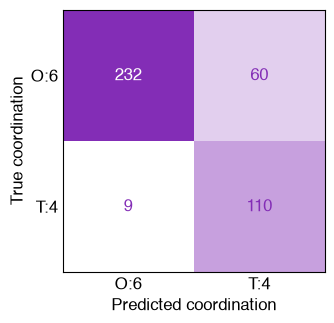

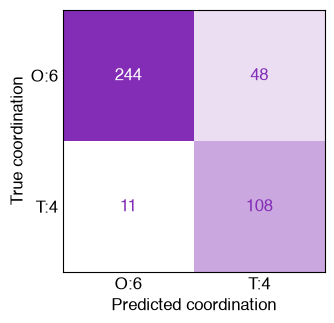

In [14]:
from xasml.models.fluorescence import calculate_spectrum

processor.reset()
processor.select_labels(LABELS, randomize=True, random_seed=RANDOM_SEED)

processor.y = np.array(label_encoder.fit_transform(processor.y))
energies = np.copy(processor.metas[0]["energies"]) + ENERGY_SHIFT
mask = processor.trim(ENERGY_MIN, ENERGY_MAX, reference=energies)
energies = energies[mask]
processor.remove_outliers(threshold=OUTLIER_THRESHOLD)
processor.split(
    test_size=0.15, val_size=0.15, random_seed=RANDOM_SEED, shuffle=True, stratify=True
)

SA_KWARGS = {
    "binder": "boron nitride",
    "phi": 45,
    "theta": 45,
    "absorbing_element": ELEMENT,
    "compound_weight_fraction": 0.1,
    "thickness": 0.1,
}

X_test_sa = np.array([
    calculate_spectrum(
        energies=energies,
        intensity=spectrum,
        compound=meta["structure"],
        **SA_KWARGS,  # type: ignore
    )
    for spectrum, meta in zip(processor.X_test, processor.metas_test)
])
X_test_sa = X_test_sa / np.trapezoid(X_test_sa, energies, axis=1)[:, np.newaxis]

y_test = label_encoder.inverse_transform(processor.y_test)

y_pred_orig = model_orig.predict(X_test_sa)
y_pred_orig = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_orig])
y_pred_aug = model_aug.predict(X_test_sa)
y_pred_aug = np.array([1 if value >= THRESHOLD else 0 for value in y_pred_aug])

print("Original model - self-absorption test:")
display_metrics(
    y_test, label_encoder.inverse_transform(y_pred_orig), display_labels=LABELS
)
print("\nAugmented model - self-absorption test:")
display_metrics(
    y_test, label_encoder.inverse_transform(y_pred_aug), display_labels=LABELS
)